In [119]:
import pymer4
import pandas as pd
import numpy as np
import pickle
import copy
from sklearn.preprocessing import StandardScaler

import scipy.stats as stats
from scipy.stats import ttest_1samp, ttest_ind, false_discovery_control
from scipy.special import expit
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, set_link_color_palette
from scipy.spatial.distance import pdist, squareform

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

base_dir = '/dartfs-hpc/rc/lab/K/KraemerD/ASL1-2_combined/2026/OSF Fig Share/' #main repo folder
data_dir = base_dir+'data/lmer_asl/'
out_dir = base_dir+'figures/'

%run '/dartfs-hpc/rc/lab/K/KraemerD/ASL1-2_combined/2026/scripts/asl_combo_helpers.py'

words = [['goat','hippo','ostrich','turtle','coconut','lemon','peach','pineapple','airplane','bulldozer','bus','spaceship'],
         ['dog','hen','mouse','tiger','apple','cherry','melon','strawberry','helicopter','sailboat','train','truck']]

all_words = words[0]+words[1]

In [80]:
# Significant Parcels from Notebook 2A
# parcel INDICES (0-499, NOT true 1-500 labels)

asl_parcs = [0, 1, 5, 26, 28, 31, 35, 50, 53, 89, 91, 106, 107, 147, 154, 155, 174, 198, 199, 200, 201, 202, 204, 238, 244, 246, 250, 259,
             270, 273, 276, 277, 281, 283, 291, 301, 308, 335, 338, 345, 356, 369, 380, 382, 383, 388, 414, 436, 441, 452, 455, 456, 457,
             490]


sig_parcs = asl_parcs

In [81]:
# for calculating R2
def r2_nakagawa_gaussian(model):
    # Variance of fixed-effect predictions (linear predictor without random effects)
    fe_pred = model.predict(model.data,use_rfx=False,pred_type="link",verify_predictions=False)
    var_f = np.var(fe_pred, ddof=0)
    
    # Random-effect variances (pymer4 exposes these via model.ranef_var)
    # ranef_var is typically a DataFrame with a 'Var' column
    var_r = model.ranef_var["Var"].sum() - model.ranef_var.loc["Residual", "Var"] \
            if "Residual" in model.ranef_var.index else model.ranef_var["Var"].sum()
    
    # Residual variance
    var_e = model.ranef_var.loc["Residual", "Var"] if "Residual" in model.ranef_var.index \
            else model.residuals.var(ddof=0)
    
    total = var_f + var_r + var_e
    r2_marginal    = var_f / total
    r2_conditional = (var_f + var_r) / total
    return r2_marginal, r2_conditional


def r2_nakagawa_binomial(model):
    # Fixed-effect linear predictor variance (on logit scale)
    fe_pred = model.predict(model.data, use_rfx=False, pred_type="link")
    var_f = np.var(fe_pred, ddof=0)
    
    # Sum of random-effect variances (these are on the logit scale for binomial)
    var_r = model.ranef_var["Var"].sum()
    # If a 'Residual' row exists for binomial (usually not, but check), exclude it:
    if "Residual" in model.ranef_var.index:
        var_r -= model.ranef_var.loc["Residual", "Var"]
    
    # Distribution-specific residual variance for logit link
    var_e = (np.pi ** 2) / 3
    
    total = var_f + var_r + var_e
    r2_marginal    = var_f / total
    r2_conditional = (var_f + var_r) / total
    return r2_marginal, r2_conditional

In [82]:
# load cross-language item distances
scores_long = pd.read_csv(data_dir+'longform_df_union_parcels_crosslanguage_distances.csv')

# subset only significant parcels:
scores_long = scores_long[scores_long['parc'].isin(sig_parcs)]
scores_long.head()

,Unnamed: 0,subID,group,item,parc,wordknown,recall_score,neuralscore
0,0,1,1,goat,0,1,0.666667,1.090748
1,1,1,1,hippo,0,1,0.666667,0.860214
2,2,1,1,ostrich,0,1,0.666667,1.276645
3,3,1,1,turtle,0,1,1.000000,1.147510
4,4,1,1,coconut,0,1,1.000000,1.347035


In [83]:
# --- Pivot: rows = parcels, columns = (subID, item) combinations ---
df_pivot = scores_long.pivot_table(
    index='parc',
    columns=['subID', 'item'],
    values='neuralscore'
)

# Flatten MultiIndex columns for clarity
df_pivot.columns = [f"sub{s}_item{i}" for s, i in df_pivot.columns]

print(f"Feature matrix shape: {df_pivot.shape}")  # (50 parcels, N_sub × N_items)
# print(df_pivot.head())

# --- Standardize features (important for clustering) ---
scaler = StandardScaler()
X = scaler.fit_transform(df_pivot)
parcel_labels = df_pivot.index.tolist()


Feature matrix shape: (54, 960)


## Determine Optimal K

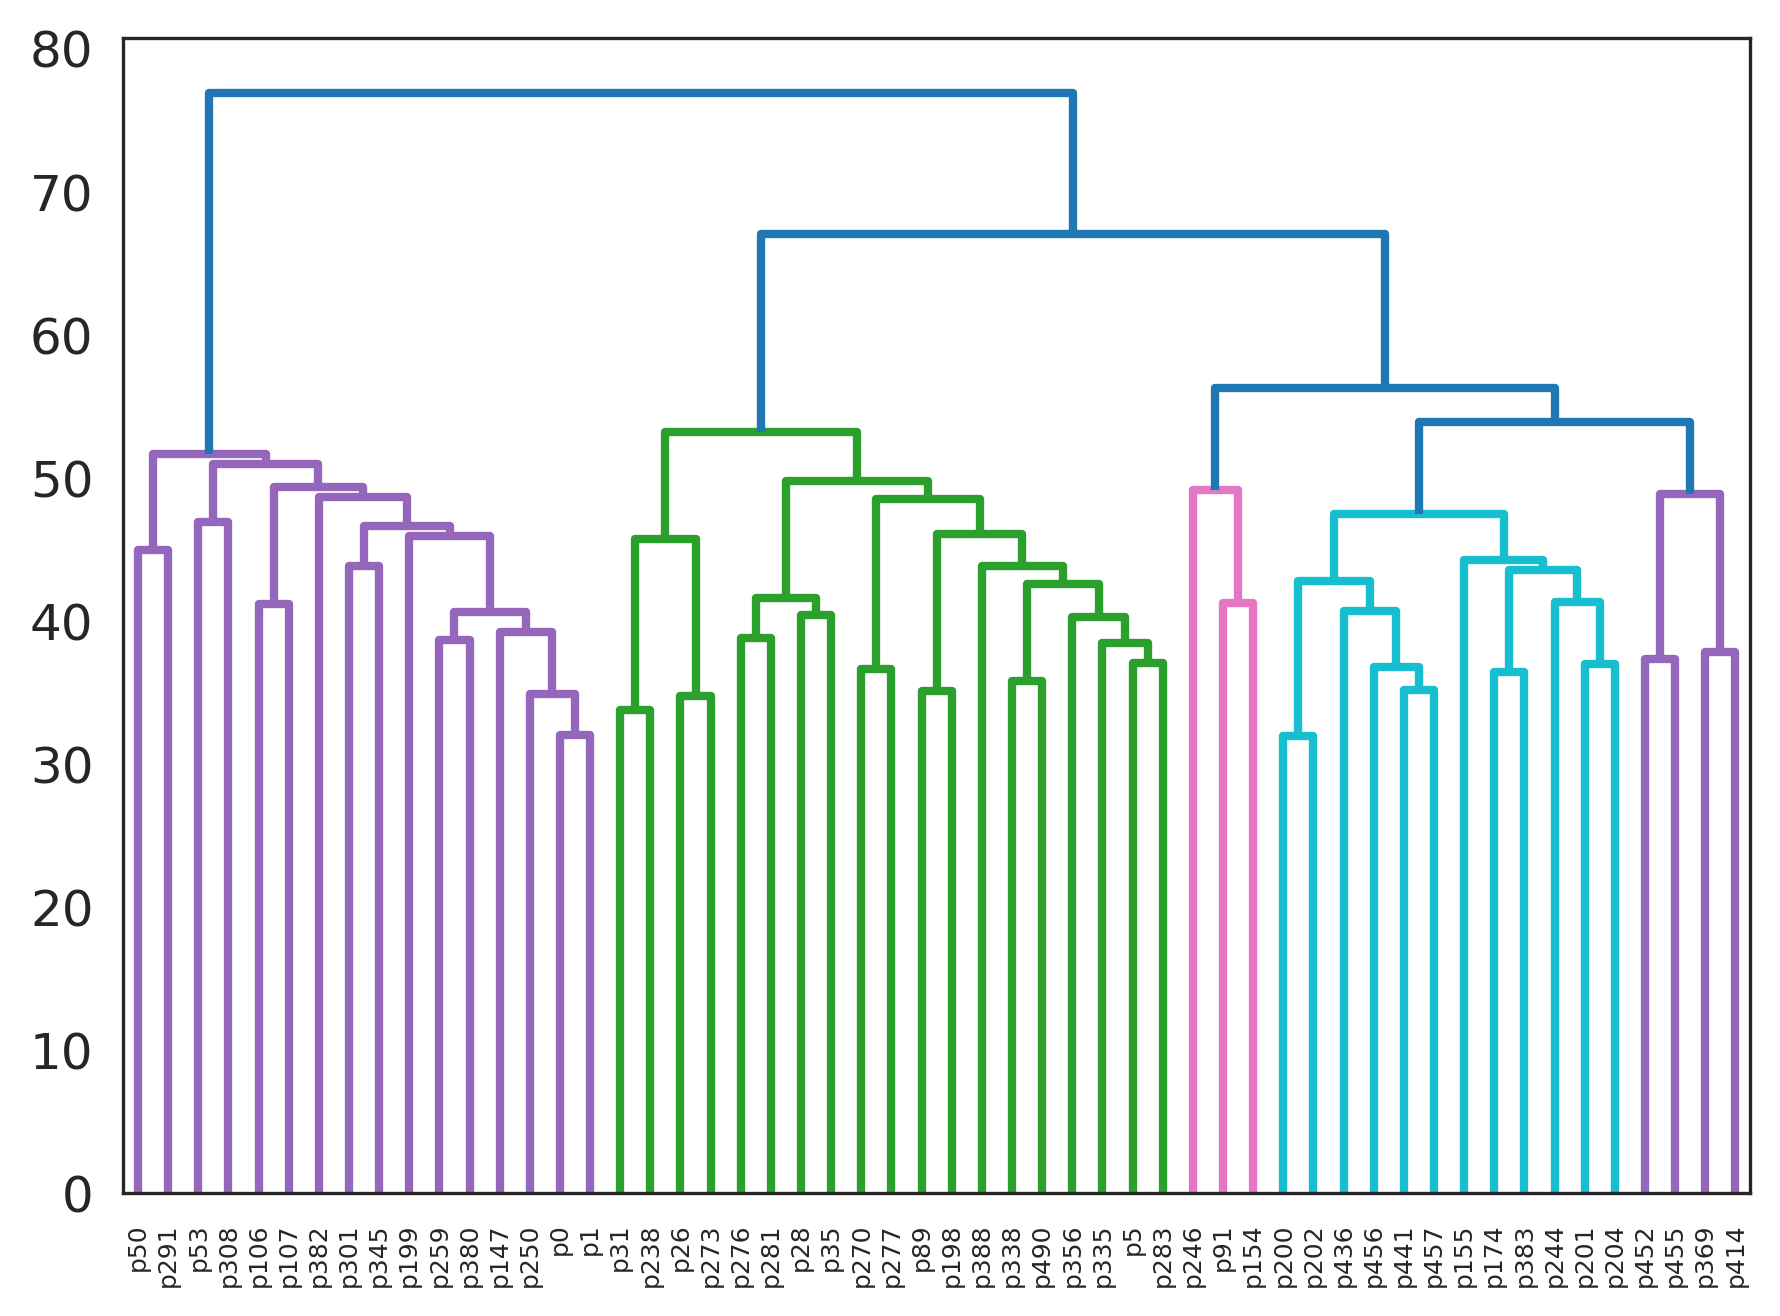

In [84]:
# Fit clustering
Z = linkage(X, method='ward')   # X = (50 parcels × features)

fig, axes = plt.subplots(1, 1, figsize=(7, 5))

# Visualize initial dendrogram
dendrogram(Z, ax=axes,labels=[f"p{p}" for p in sig_parcs],leaf_rotation  = 90);

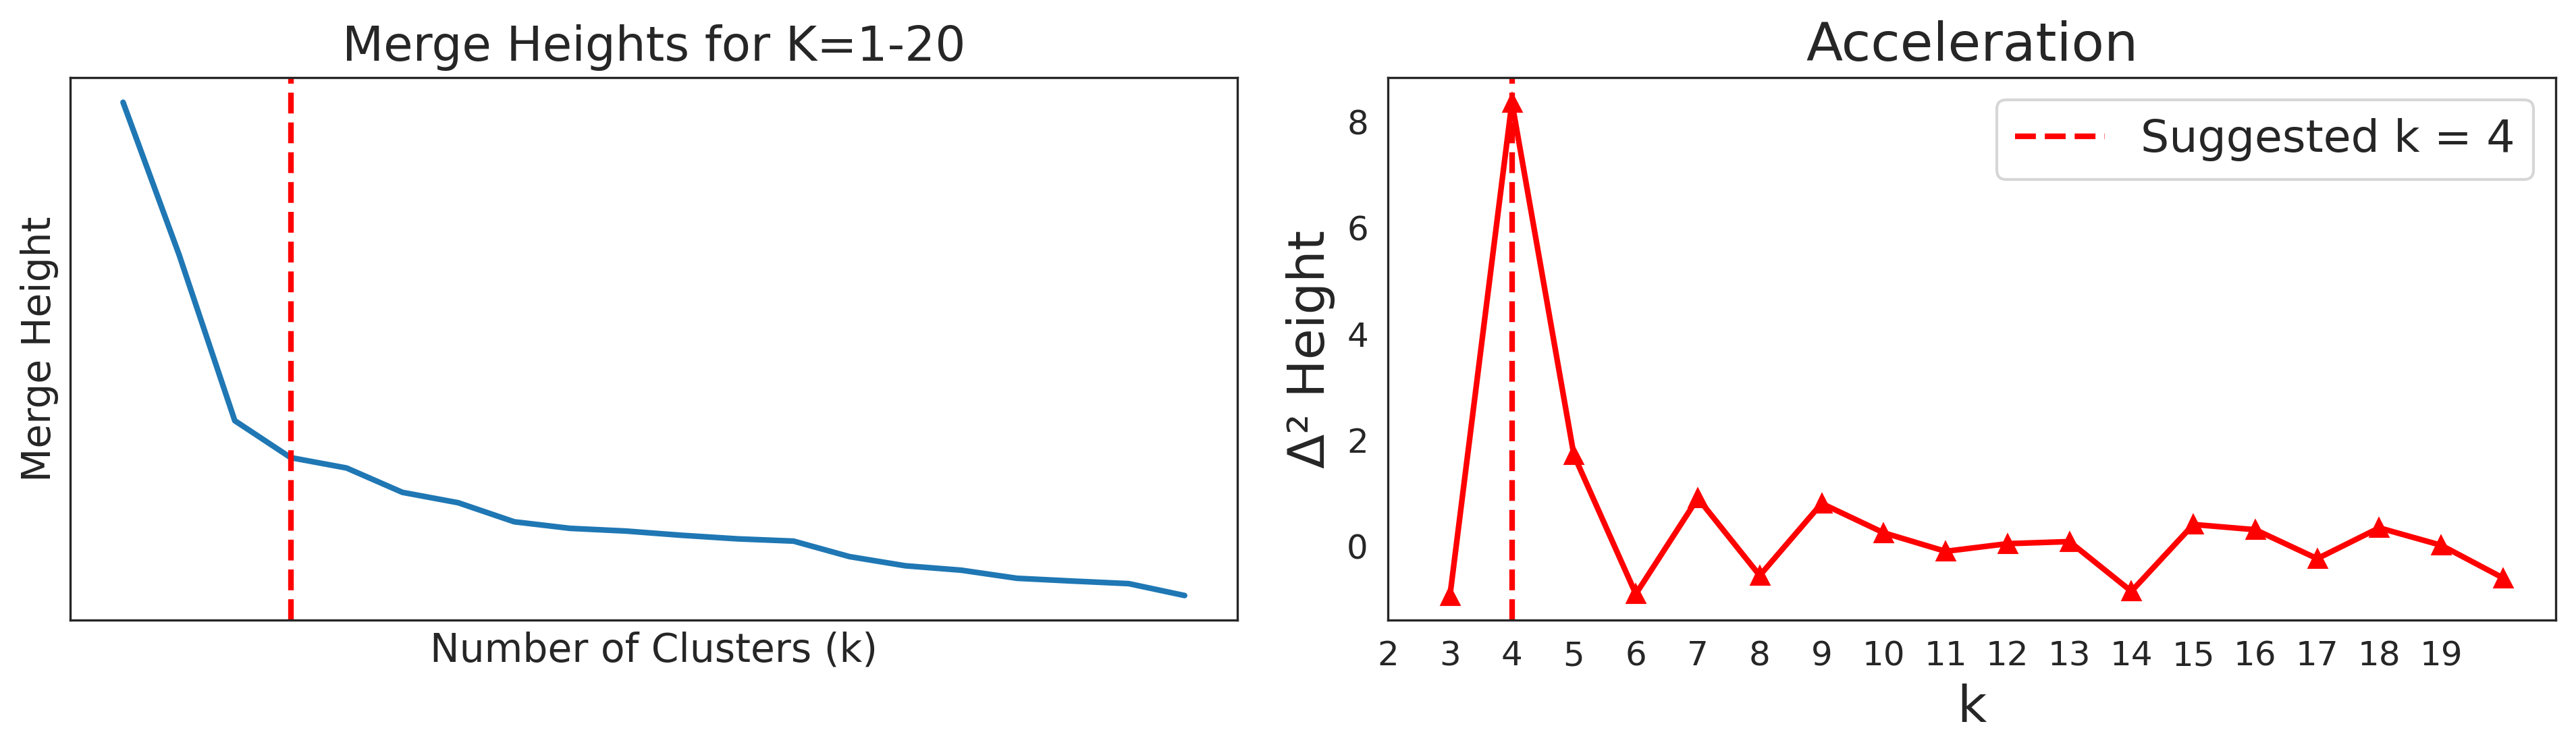

In [85]:
# Elbow method: tradeoff between cluster size and dendrogram merge height (optimal = inflection point)
# Acceleration: Second derivative of merge height change (optimal = highest)

# how many values of K to test
n_ks = 20
heights = Z[-n_ks:, 2][::-1]   # take the last N merges, reverse: large to small
k_values = np.arange(1, n_ks + 1)

# Calculate second derivative
acceleration  = np.diff(heights, 2) # second derivative
acceleration_k = k_values[2:] # aligns with second diff

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Merge heights over K range
axes[0].plot(k_values, heights)
axes[0].set_xlabel('Number of Clusters (k)',fontsize=14)
axes[0].set_ylabel('Merge Height',fontsize=14)
axes[0].set_yticks([])
axes[0].set_xticks([]) #np.arange(2,20))
axes[0].set_title("Merge Heights for K=1-"+str(n_ks),fontsize=17)

# Acceleration
axes[1].plot(acceleration_k, acceleration, 'r^-')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Δ² Height')
axes[1].set_xticks(np.arange(2,20))
axes[1].set_title('Acceleration')

best_k_accel = int(acceleration_k[np.argmax(acceleration)])
axes[1].axvline(best_k_accel, color='red', linestyle='--',
                label=f'Suggested k = {best_k_accel}')
axes[1].legend()

# visualize how this threshold aligns with the "elbow" of the raw merge heights
axes[0].axvline(best_k_accel, color='red', linestyle='--',
                label=f'Suggested k = {best_k_accel}')

plt.tight_layout()

axes[0].set_facecolor('white')
axes[1].set_facecolor('white')
fig.patch.set_alpha(0)
plt.savefig(out_dir+'cluster_k_comparison_asl.png')
plt.show()

In [86]:
# K=4 is a reasonable choice according to each of these methods.
# Based on dendrogram above, determine what cut height produces that solution
k=4
CHOSEN_THRESHOLD = 56

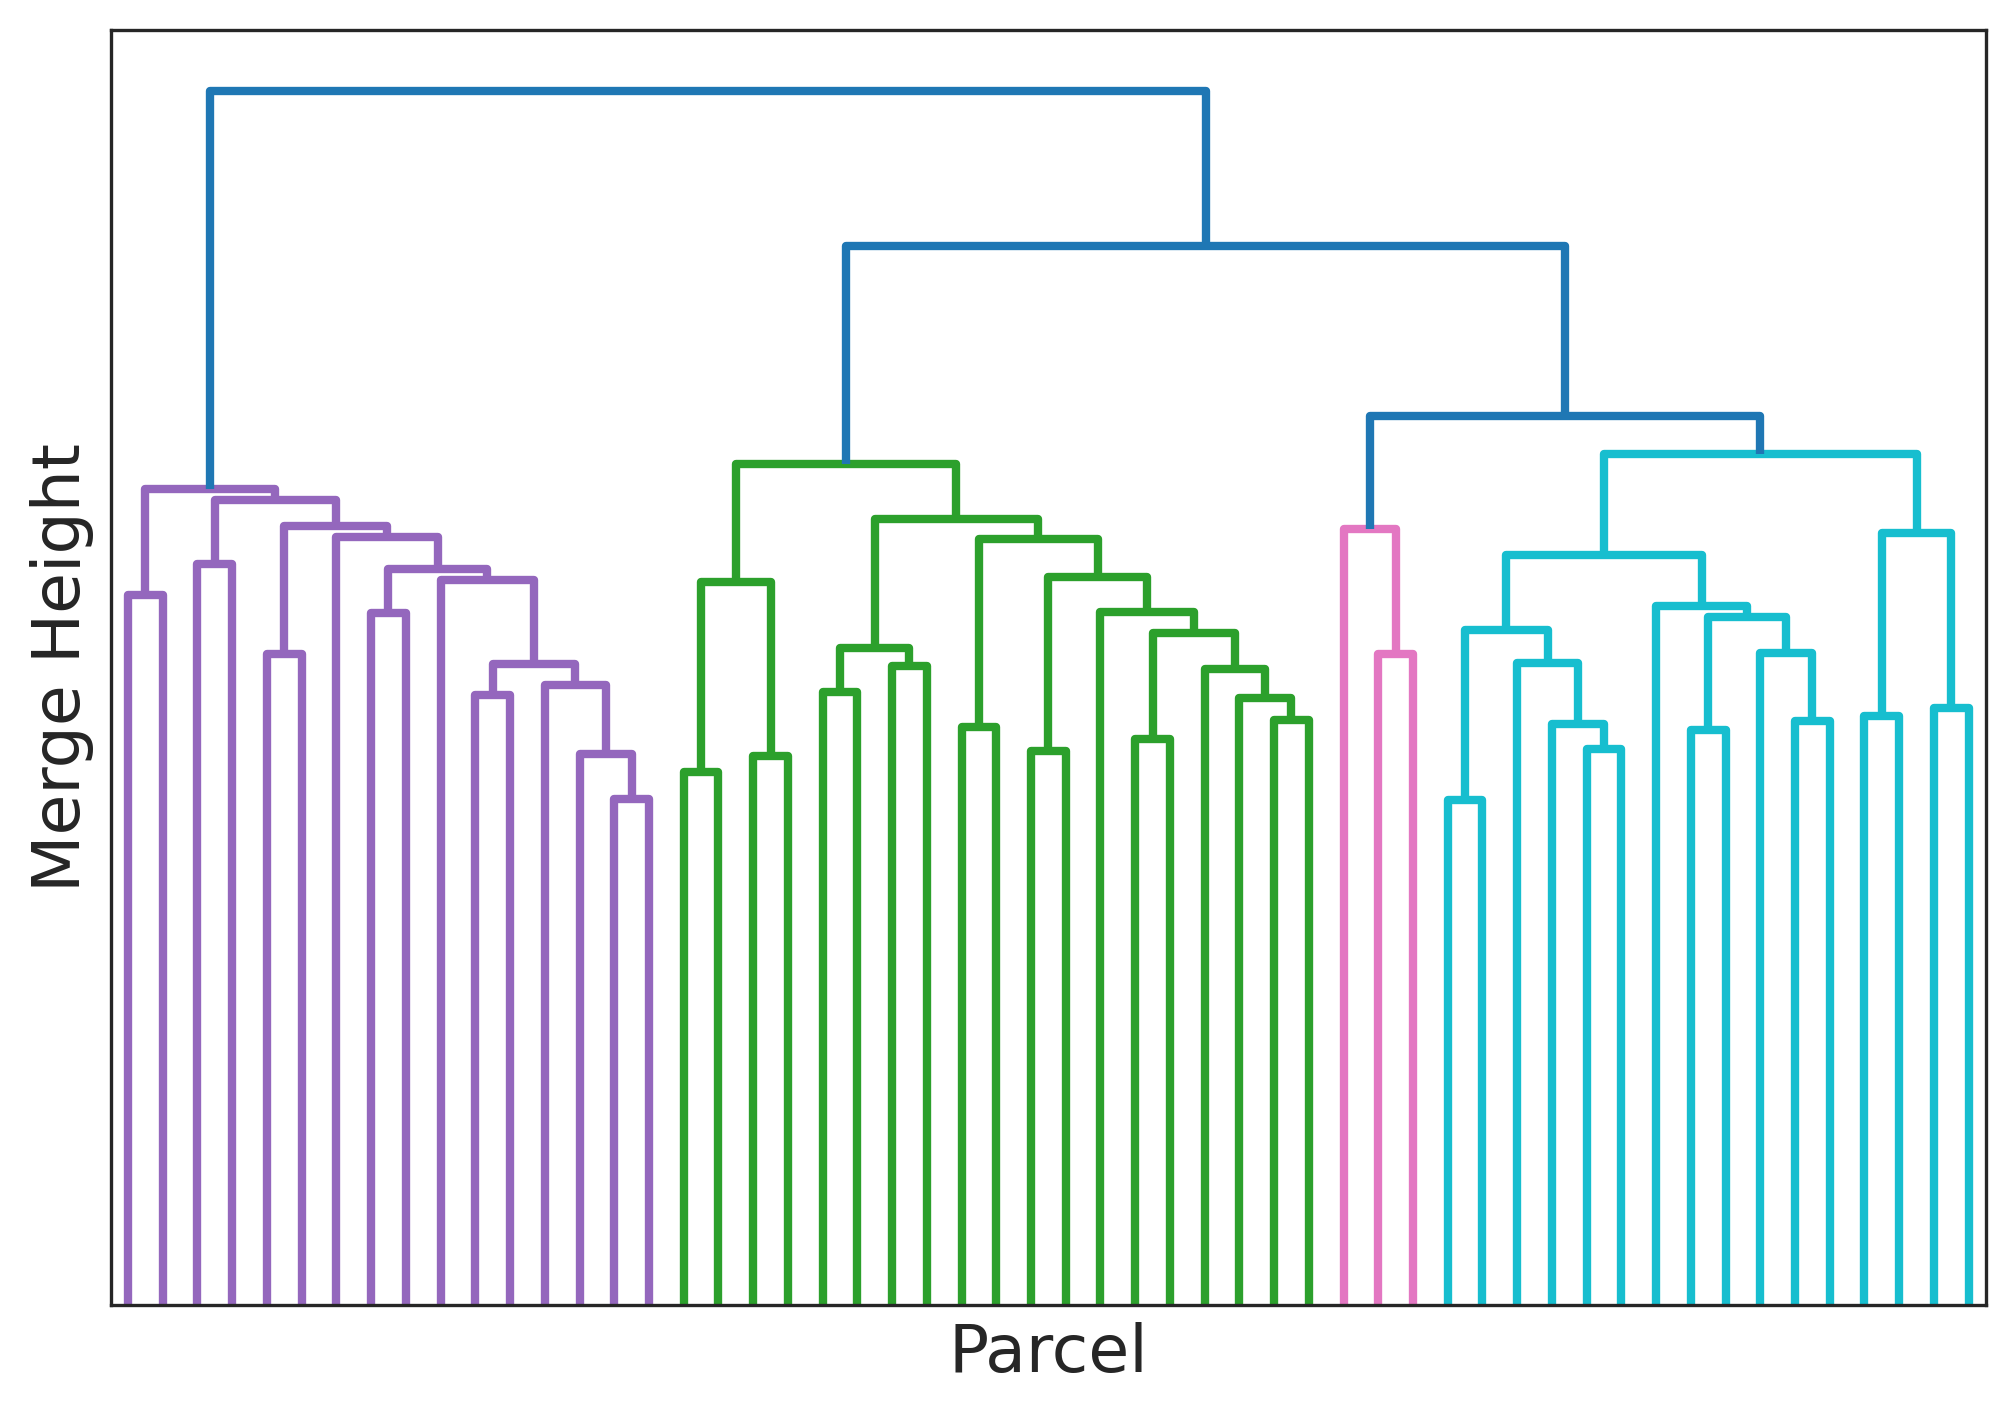

In [87]:
# Plot dendrogram again with chosen cut point

Z = linkage(X, method='ward')   # X = (50 parcels × features)

fig, axes = plt.subplots(1, 1, figsize=(7,5)) #figsize=(9, 5))

cluster_colors = ['#9467bd', '#2ca02c', '#e377c2', '#17becf']
set_link_color_palette(cluster_colors)

# Left: dendrogram
dendrogram(
    Z,
    ax             = axes,
    labels         = [f"p{p}" for p in sig_parcs],
    leaf_rotation  = 90,
    color_threshold= 56,
)
# axes.set_title('Dendrogram (Ward linkage)',fontsize=20)
axes.set_xlabel('Parcel',fontsize=16)
axes.set_ylabel('Merge Height',fontsize=16)
axes.set_xticks([])
axes.set_yticks([])
plt.tight_layout()

axes.set_facecolor('white')
fig.patch.set_alpha(0)
plt.savefig(out_dir+'k'+str(k)+'_dendrogram_asl.png')
plt.show()

In [89]:
# add cluster labels to df
final_labels = fcluster(Z, CHOSEN_THRESHOLD, criterion='distance')
k      = len(np.unique(final_labels))

parcel_assignments = pd.DataFrame({
    'parc'   : sig_parcs,
    'cluster': final_labels
}).sort_values('cluster')

print(f"Chosen threshold : {CHOSEN_THRESHOLD:.4f}")
print(f"Resulting k      : {k}")
print(f"\nCluster sizes:")
print(parcel_assignments['cluster'].value_counts().sort_index())

# add to scores_long
cs =[]
for row in list(scores_long['parc']):
    cs.append(list(parcel_assignments[parcel_assignments['parc'] == row]['cluster'])[0])

scores_long['cluster'] = cs

Chosen threshold : 56.0000
Resulting k      : 4

Cluster sizes:
cluster
1    16
2    19
3     3
4    16
Name: count, dtype: int64


In [37]:
scores_long.to_csv('temp.csv')

### Plot brain colormap of clusters:

In [ ]:
cluster_cmap = ListedColormap(cluster_colors)

# Plot heatmap of clusters
parc_vals = np.zeros(500)

for p, c in zip(parcel_assignments['parc'],parcel_assignments['cluster']):
    parc_vals[p] = c

plot = True

if plot:
    rh_masked, lh_masked = parc_list_to_surf(parc_vals, 500)
    fn = out_dir+'ASL-Combo_hierarchical_clustered_RSA_asl_parcs_normed_'+str(k)
    four_panel_surfplot(rh_masked, lh_masked,fn,title="hierarchical clustered parcs (K="+str(k)+")",
                        colormap=cluster_cmap,bg_on_data=True,cmap_method='range')


# GLMER: Predict whether sign was studied based on neural score

In [90]:
# global z-score across all obs (helpful for putting later estimates on the same scale)
scores_long['neuralscore_norm'] = stats.zscore(scores_long['neuralscore'])
scores_long.head()

,Unnamed: 0,subID,group,item,parc,wordknown,recall_score,neuralscore,cluster,neuralscore_norm
0,0,1,1,goat,0,1,0.666667,1.090748,1,-0.156335
1,1,1,1,hippo,0,1,0.666667,0.860214,1,-0.878004
2,2,1,1,ostrich,0,1,0.666667,1.276645,1,0.425604
3,3,1,1,turtle,0,1,1.000000,1.147510,1,0.021357
4,4,1,1,coconut,0,1,1.000000,1.347035,1,0.645955


In [91]:
scores_byclust = scores_long[['subID','item','wordknown','recall_score','neuralscore','neuralscore_norm','cluster']]
scores_byclust = scores_byclust.groupby(['subID', 'item', 'cluster'], as_index=False).mean()

In [92]:
# fit binomial (logistic) model
model = pymer4.Lmer("wordknown ~ neuralscore_norm + (1|cluster) + (1|subID) + (1|item)",family='binomial',data=scores_byclust)
results_df = model.fit()

beta_obs=list(results_df['Estimate'])[1]
p_obs=list(results_df['P-val'])[1]
se_obs=list(results_df['SE'])[1]

results_df

boundary (singular) fit: see help('isSingular') 

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: wordknown~neuralscore_norm+(1|cluster)+(1|subID)+(1|item)

Family: binomial	 Inference: parametric

Number of observations: 3840	 Groups: {'subID': 40.0, 'item': 24.0, 'cluster': 4.0}

Log-likelihood: -2656.181 	 AIC: 5322.361

Random effects:

                Name  Var  Std
subID    (Intercept)  0.0  0.0
item     (Intercept)  0.0  0.0
cluster  (Intercept)  0.0  0.0

No random effect correlations specified

Fixed effects:



,Estimate,2.5_ci,97.5_ci,SE,OR,OR_2.5_ci,OR_97.5_ci,Prob,Prob_2.5_ci,Prob_97.5_ci,Z-stat,P-val,Sig
(Intercept),-0.004,-0.068,0.059,0.032,0.996,0.934,1.061,0.499,0.483,0.515,-0.138,0.890,
neuralscore_norm,0.181,0.074,0.288,0.055,1.199,1.077,1.334,0.545,0.518,0.572,3.310,0.001,***


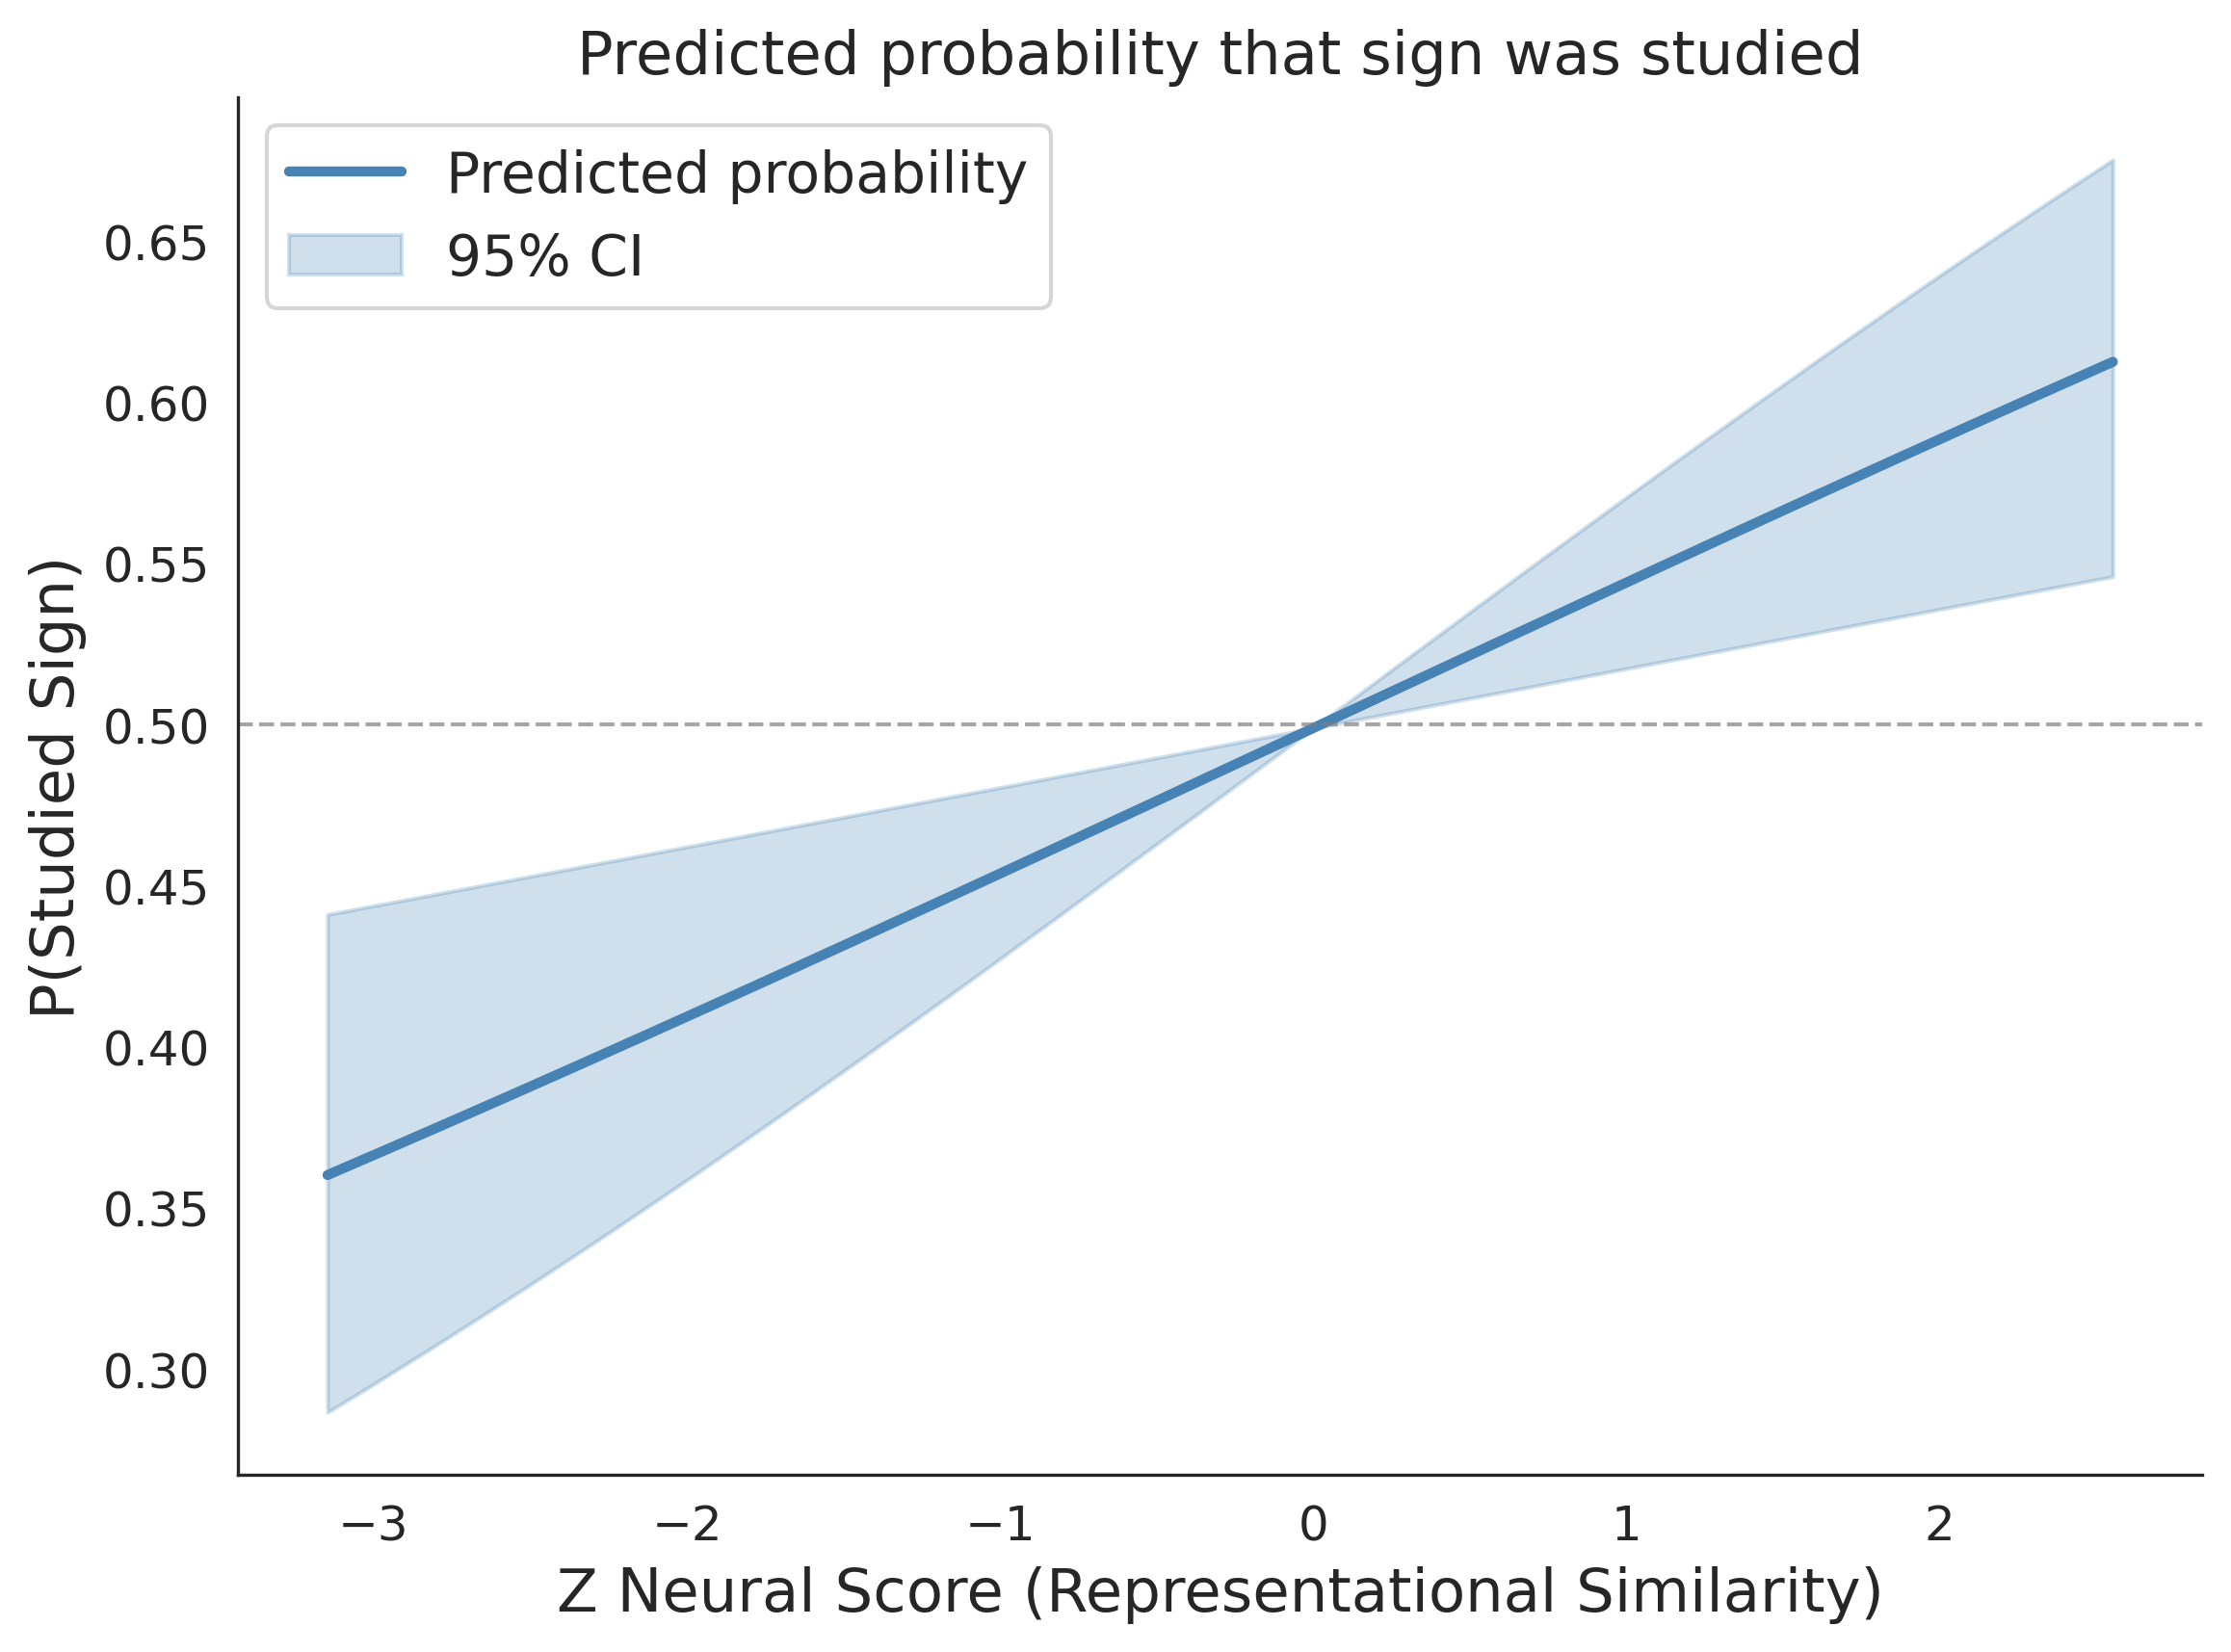

In [94]:
# Extract fixed effects from fitted model
intercept = model.coefs.loc['(Intercept)', 'Estimate']
slope     = model.coefs.loc['neuralscore_norm',  'Estimate']
se_slope  = model.coefs.loc['neuralscore_norm',  'SE']

# Create range of neural score values
x = np.linspace(scores_long['neuralscore_norm'].min(),
                scores_long['neuralscore_norm'].max(), 300)

# Predicted log-odds and probability
log_odds = intercept + slope * x
prob     = expit(log_odds)

# Confidence band (on log-odds scale, then transform)
log_odds_upper = intercept + (slope + 1.96 * se_slope) * x
log_odds_lower = intercept + (slope - 1.96 * se_slope) * x
prob_upper = expit(log_odds_upper)
prob_lower = expit(log_odds_lower)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(x, prob, color='steelblue', linewidth=2.5, label='Predicted probability')
ax.fill_between(x, prob_lower, prob_upper,
                alpha=0.25, color='steelblue', label='95% CI')

ax.set_xlabel('Z Neural Score (Representational Similarity)', fontsize=15)
ax.set_ylabel('P(Studied Sign)', fontsize=15)
ax.set_title('Predicted probability that sign was studied', fontsize=15)
# ax.set_ylim(0.2, 0.8)
# ax.set_yticks([.6,.55,.5,.45,.4],labels=[0.60,0.55,0.50,0.45,0.40],size=13)
# ax.set_xticks([0,.25,.5,.75,1,1.25,1.5,1.75,2],labels=[0,0.25,0.5,0.75,1.00,1.25,1.50,1.75,2.00],size=13)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.legend(fontsize=14)
sns.despine()
plt.tight_layout()
plt.show()

In [54]:
r2m, r2c = r2_nakagawa_binomial(model)
print(f"Marginal R²  = {r2m:.3f}")

Marginal R²  = 0.003
Conditional R² = 0.003


# Post-Hoc: By Cluster

In [95]:
pd.options.mode.chained_assignment = None # allow silent rewriting of the cluster df on each loop

betas=[]
ps=[]
ci_uppers=[]
ci_lowers=[]
se = []
r_marg = []

for c in np.unique(list(scores_long['cluster'])):
    df = scores_long[scores_long['cluster'] == c]

    df['neuralscore_c'] = stats.zscore(df['neuralscore_norm'])

    model = pymer4.Lmer("wordknown ~ neuralscore_c + (1|parc) + (1|subID) + (1|item)",family='binomial',data=df);
    results_df = model.fit()
    betas.append(list(results_df['Estimate'])[1])
    ps.append(list(results_df['P-val'])[1])
    ci_uppers.append(list(results_df['97.5_ci'])[1])
    ci_lowers.append(list(results_df['2.5_ci'])[1])
    se.append(list(results_df['SE'])[1])

    r2m, r2c = r2_nakagawa_binomial(model)
    r_marg.append(r2m)


print(r_marg)
print(false_discovery_control(ps))

boundary (singular) fit: see help('isSingular') 

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: wordknown~neuralscore_c+(1|parc)+(1|subID)+(1|item)

Family: binomial	 Inference: parametric

Number of observations: 15360	 Groups: {'subID': 40.0, 'item': 24.0, 'parc': 16.0}

Log-likelihood: -10643.162 	 AIC: 21296.325

Random effects:

              Name  Var  Std
subID  (Intercept)  0.0  0.0
item   (Intercept)  0.0  0.0
parc   (Intercept)  0.0  0.0

No random effect correlations specified

Fixed effects:

boundary (singular) fit: see help('isSingular') 

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: wordknown~neuralscore_c+(1|parc)+(1|subID)+(1|item)

Family: binomial	 Inference: parametric

Number of observations: 18240	 Groups: {'subID': 40.0, 'item': 24.0, 'parc': 19.0}

Log-likelihood: -12641.680 	 AIC: 25293.360

Random effects:

              Name  Var  Std
subID  (Intercept)  0.0  0.0
item   (Intercept)  0.0  0.0
parc   (Intercept)  0.0  

In [105]:
all_ps

[0.001, 0.009333333333333332, 0.104, 0.004, 0.004]

[0.00933333 0.104      0.004      0.004     ]


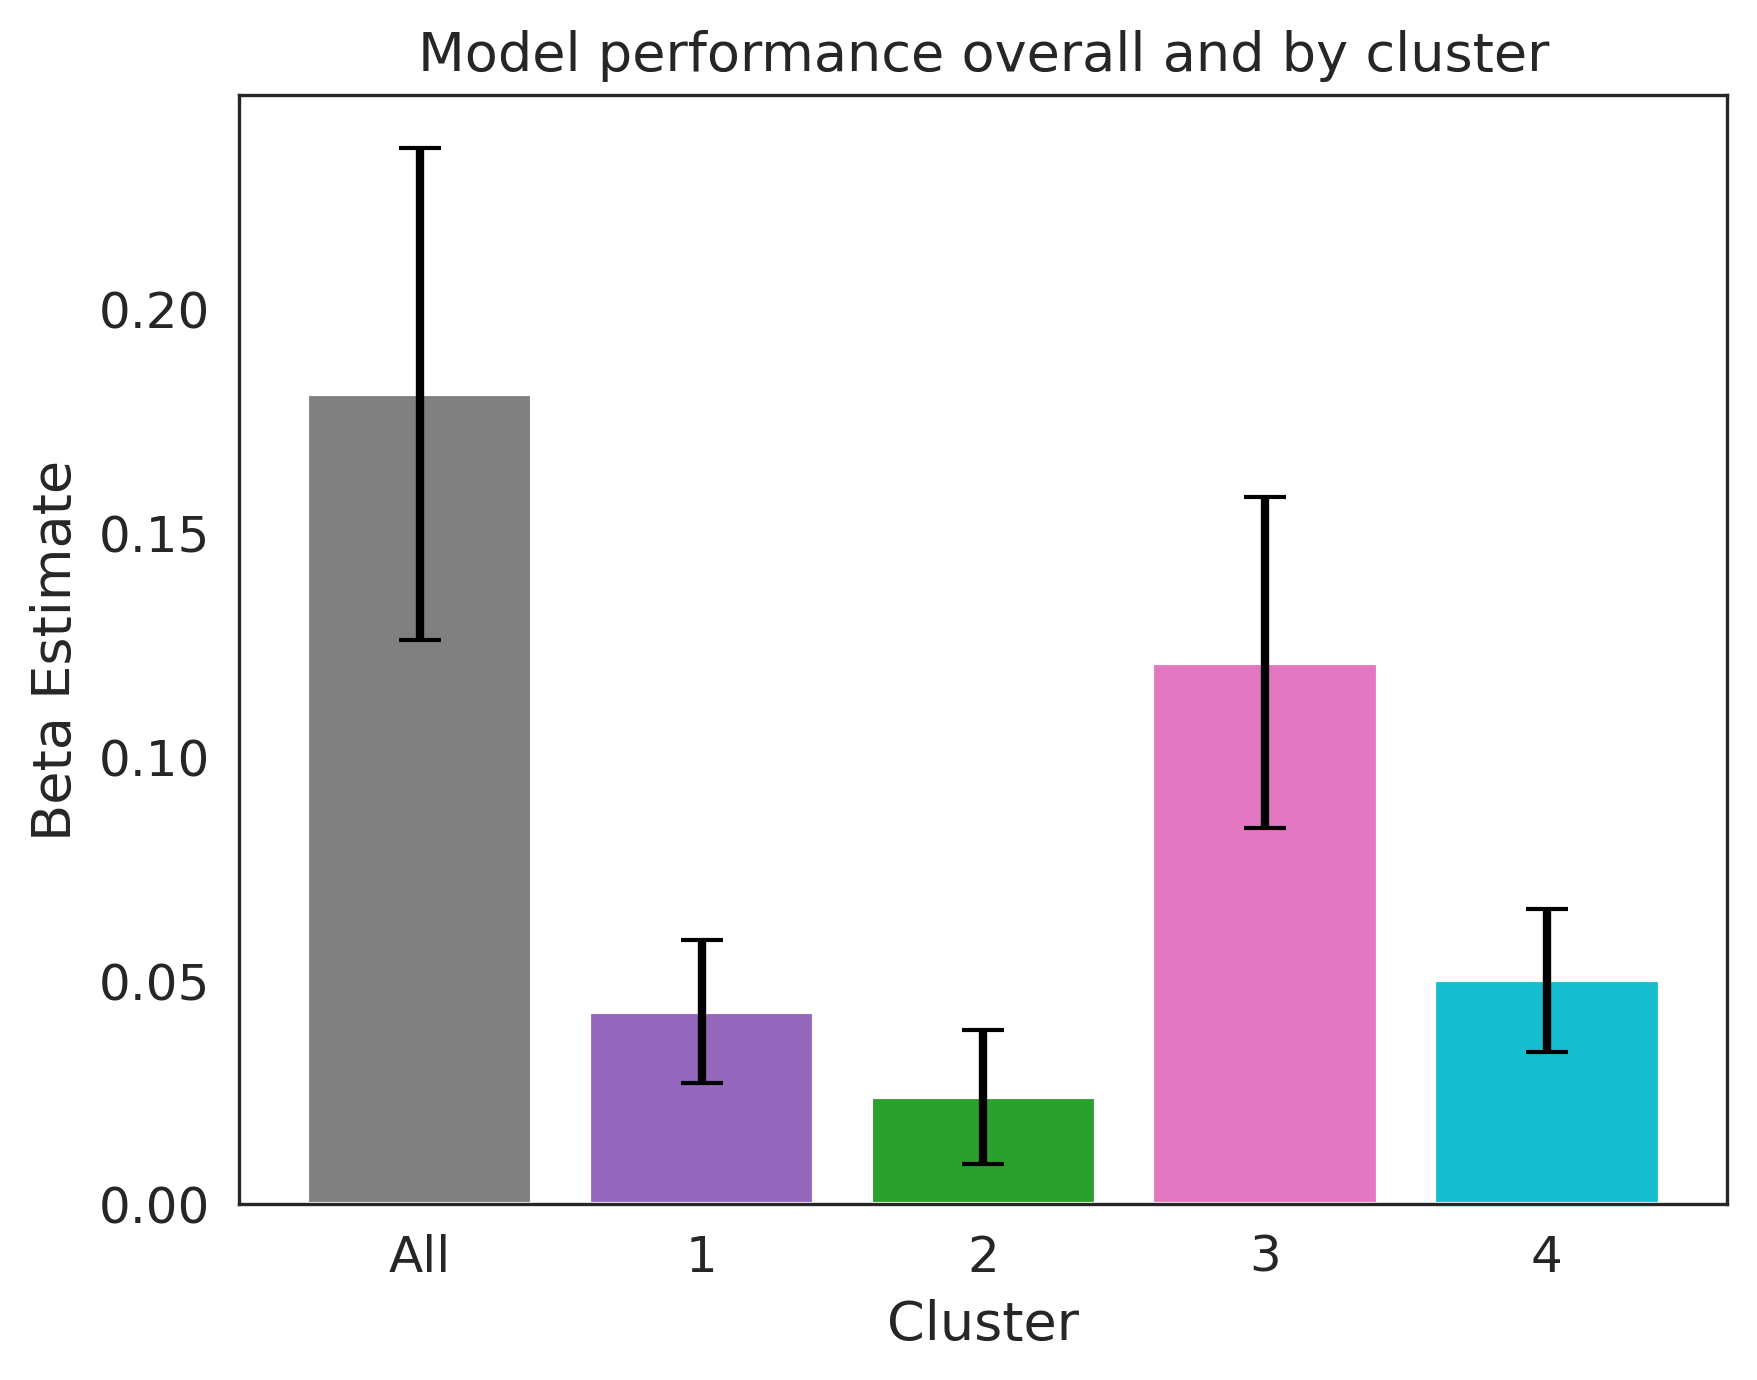

In [107]:
print(false_discovery_control(ps))

all_betas=[beta_obs]+betas
all_ps=[p_obs]+list(false_discovery_control(ps))
# all_se = [se_obs]+se
colors = ['grey'] + cluster_colors

plt.bar(range(len(all_betas)), all_betas, color=colors,capsize=5,yerr=all_se) #yerr=[error_lower, error_upper])
plt.title("Model performance overall and by cluster",fontsize=13)
plt.xlabel("Cluster",fontsize=13)
plt.ylabel("Beta Estimate",fontsize=13)
plt.xticks(np.arange(k+1),labels=['All'] + [str(n) for n in range(1,k+1)]);

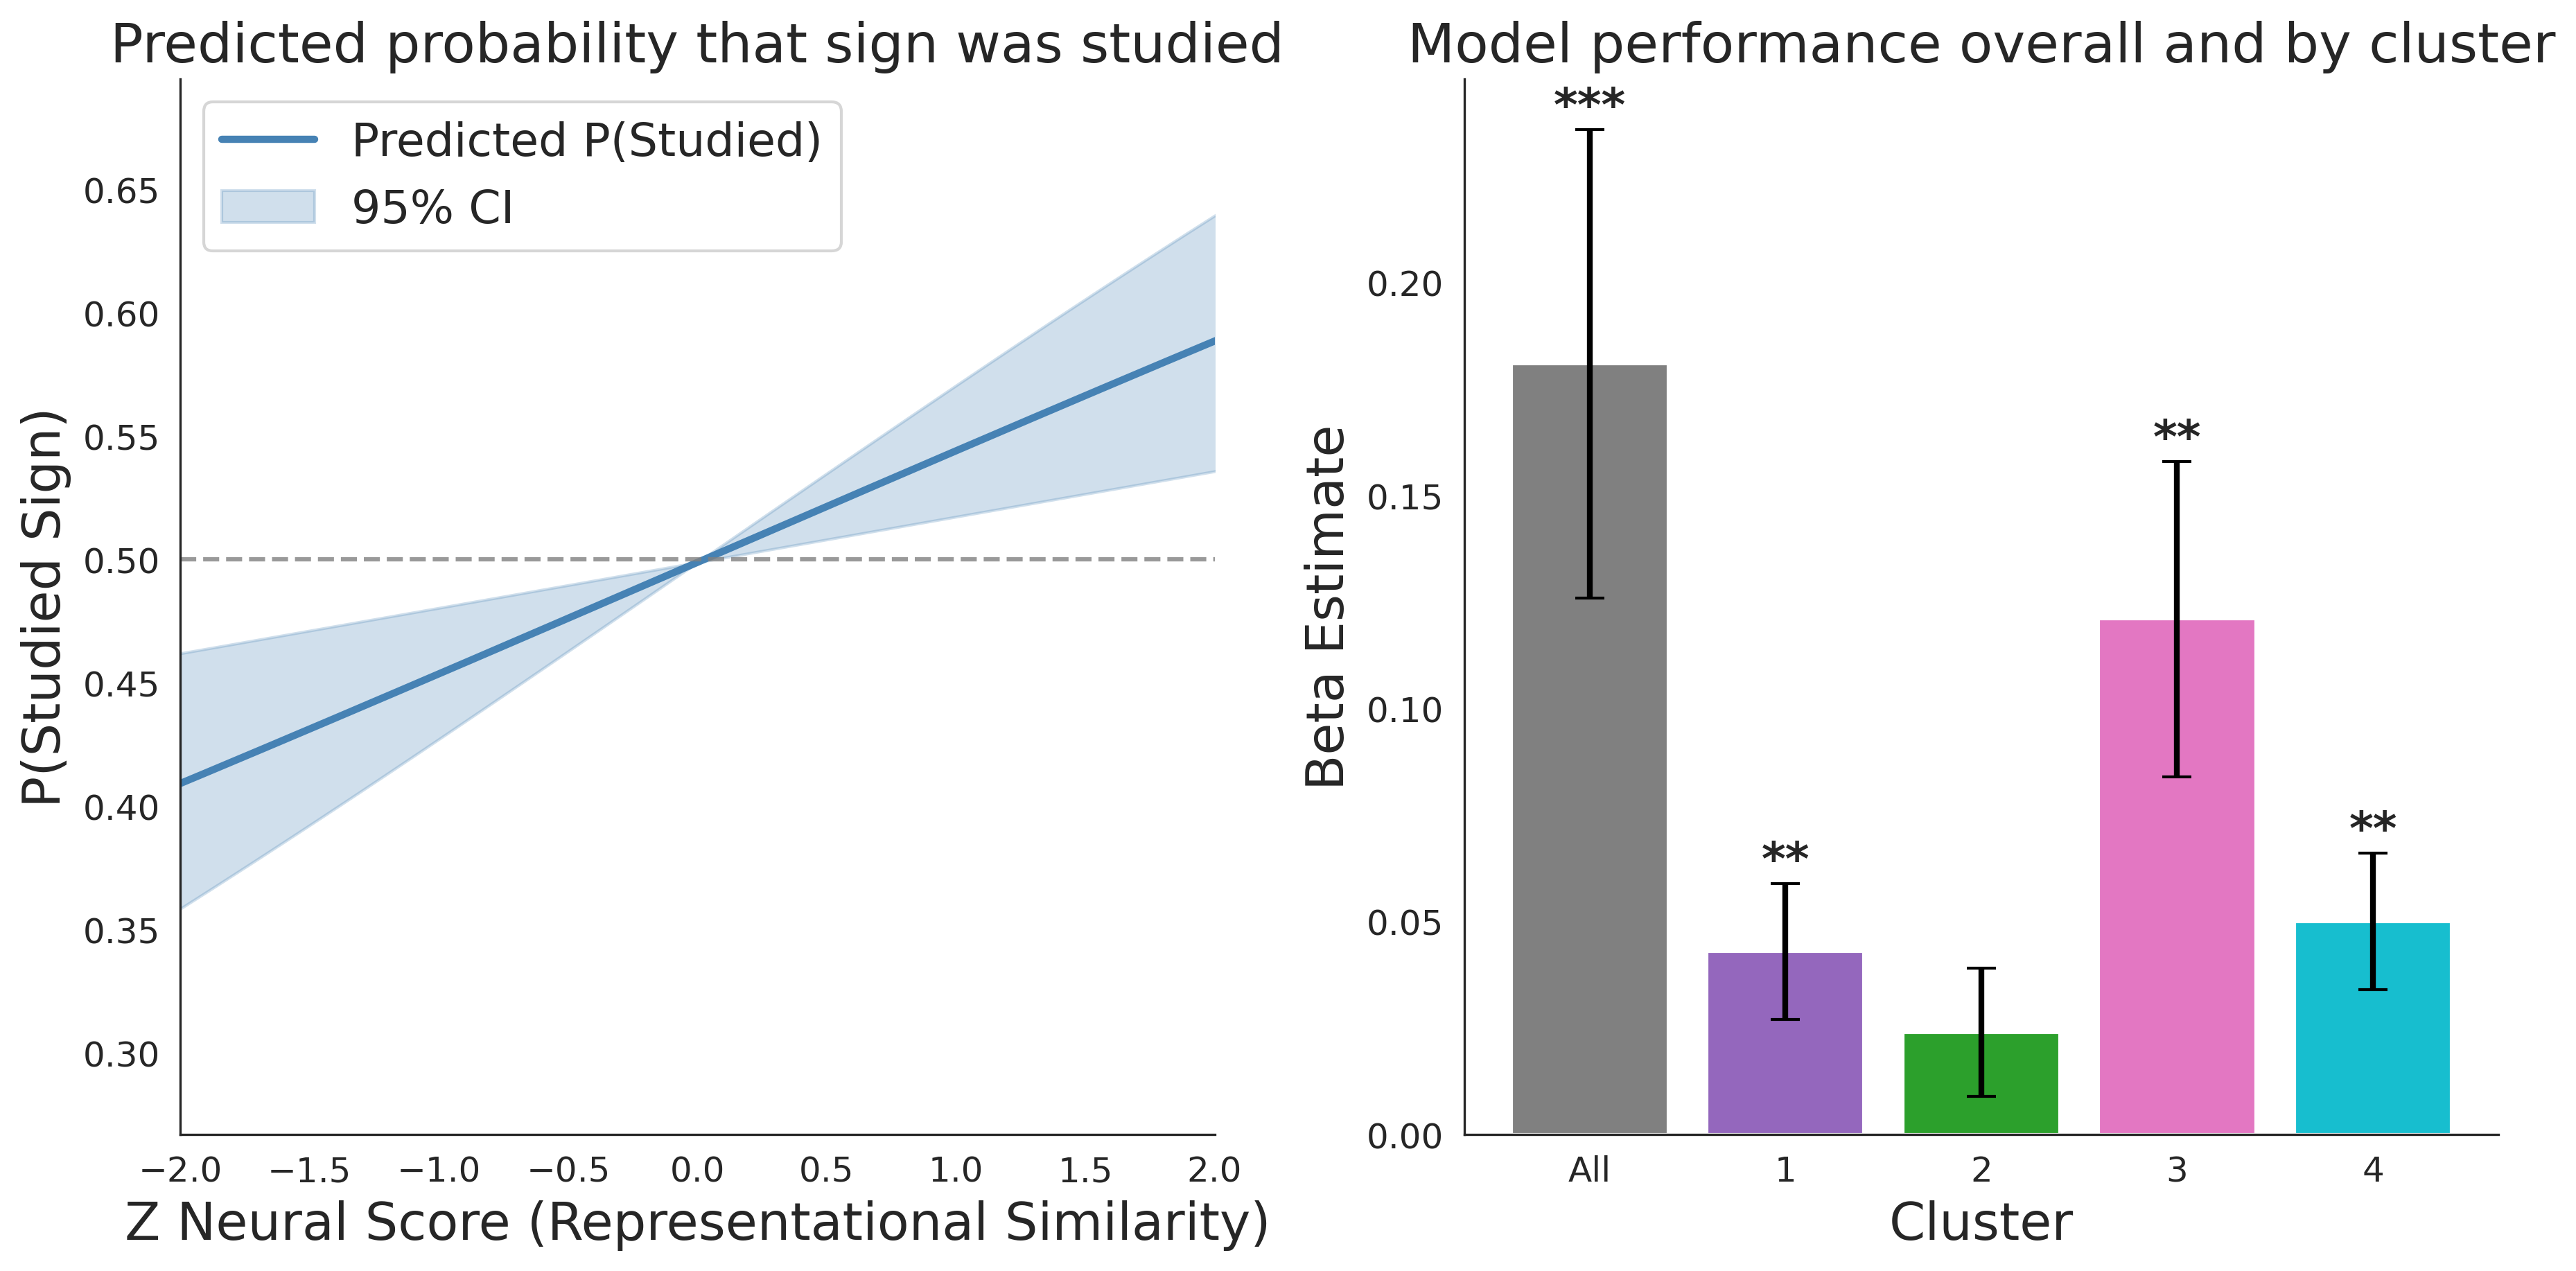

In [108]:
# Combination plot with both linear model and by-cluster betas:

sns.set_style("white")
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 19,
    "axes.labelsize": 18, 
    "legend.fontsize": 16,
    "xtick.labelsize": 12, 
    "ytick.labelsize": 12,
    "lines.linewidth": 2,
    "figure.dpi": 300
})
fig, (ax1, ax2) = plt.subplots(nrows=1,ncols=2, figsize=(12, 6),constrained_layout=True,gridspec_kw={"wspace":0.05})

# regression plot
ax1.plot(x, prob,color="steelblue",linewidth=2.5,label="Predicted P(Studied)")

# regression CI band
ax1.fill_between(x,prob_lower,prob_upper,color="steelblue",alpha=0.25,label="95% CI")

ax1.set_xlabel("Z Neural Score (Representational Similarity)")
ax1.set_ylabel("P(Studied Sign)")
ax1.set_title("Predicted probability that sign was studied")
ax1.axhline(0.5, color="gray", linestyle="--", linewidth=1.5, alpha=0.8)
ax1.set_xlim(-2,2)

ax1.legend()
sns.despine(ax=ax1)

bars = ax2.bar(np.arange(len(all_betas)),all_betas, color=colors, yerr=all_se, capsize=5,)

ax2.set_title("Model performance overall and by cluster")
ax2.set_xlabel("Cluster")
ax2.set_ylabel("Beta Estimate")

ax2.set_xticks(np.arange(k + 1))
ax2.set_xticklabels(["All"] + [str(n) for n in range(1, k + 1)])

# add significance stars
for bar, p, se in zip(bars, all_ps, all_se):
    if p <= 0.001:
        star = "***"
    elif p < 0.01:
        star = "**"
    elif p < 0.05:
        star = "*"
    else:
        continue

    height = bar.get_height()
    x_center = bar.get_x() + bar.get_width() / 2.0
    y_pos = height + se
    ax2.text(x_center, y_pos, star, ha="center", va="bottom",fontsize=16,fontweight='bold')

sns.despine(ax=ax2)


# LMER: Predict whether studied sign was *recalled* by each participant

In [109]:
# subset scores_long even further: now, only include "studied" signs (from each participant's known word list)
scores_known = scores_long[scores_long['wordknown'] == 1]
scores_known.head()

,Unnamed: 0,subID,group,item,parc,wordknown,recall_score,neuralscore,cluster,neuralscore_norm
0,0,1,1,goat,0,1,0.666667,1.090748,1,-0.156335
1,1,1,1,hippo,0,1,0.666667,0.860214,1,-0.878004
2,2,1,1,ostrich,0,1,0.666667,1.276645,1,0.425604
3,3,1,1,turtle,0,1,1.000000,1.147510,1,0.021357
4,4,1,1,coconut,0,1,1.000000,1.347035,1,0.645955


In [110]:
scores_byclust = scores_known[['subID','item','recall_score','neuralscore','neuralscore_norm','cluster']]
scores_byclust = scores_byclust.groupby(['subID', 'item', 'cluster'], as_index=False).mean()

scores_byclust['neuralscore_z'] = stats.zscore(scores_byclust['neuralscore'])

model = pymer4.Lmer("recall_score ~ neuralscore_norm + (1|cluster) + (1|subID) + (1|item)",data=scores_byclust)
results_df = model.fit()

beta_obs=list(results_df['Estimate'])[1]
p_obs=list(results_df['P-val'])[1]
se_obs=list(results_df['SE'])[1]

results_df

boundary (singular) fit: see help('isSingular') 

Linear mixed model fit by REML [’lmerMod’]
Formula: recall_score~neuralscore_norm+(1|cluster)+(1|subID)+(1|item)

Family: gaussian	 Inference: parametric

Number of observations: 1920	 Groups: {'subID': 40.0, 'item': 24.0, 'cluster': 4.0}

Log-likelihood: 202.575 	 AIC: -393.151

Random effects:

                 Name    Var    Std
subID     (Intercept)  0.011  0.103
item      (Intercept)  0.010  0.102
cluster   (Intercept)  0.000  0.000
Residual               0.043  0.208

No random effect correlations specified

Fixed effects:



,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),0.870,0.817,0.922,0.027,46.091,32.332,0.000,***
neuralscore_norm,0.019,0.002,0.036,0.009,1900.223,2.134,0.033,*


In [111]:
marg, cond = r2_nakagawa_gaussian(model)
marg

0.0019813317640749134

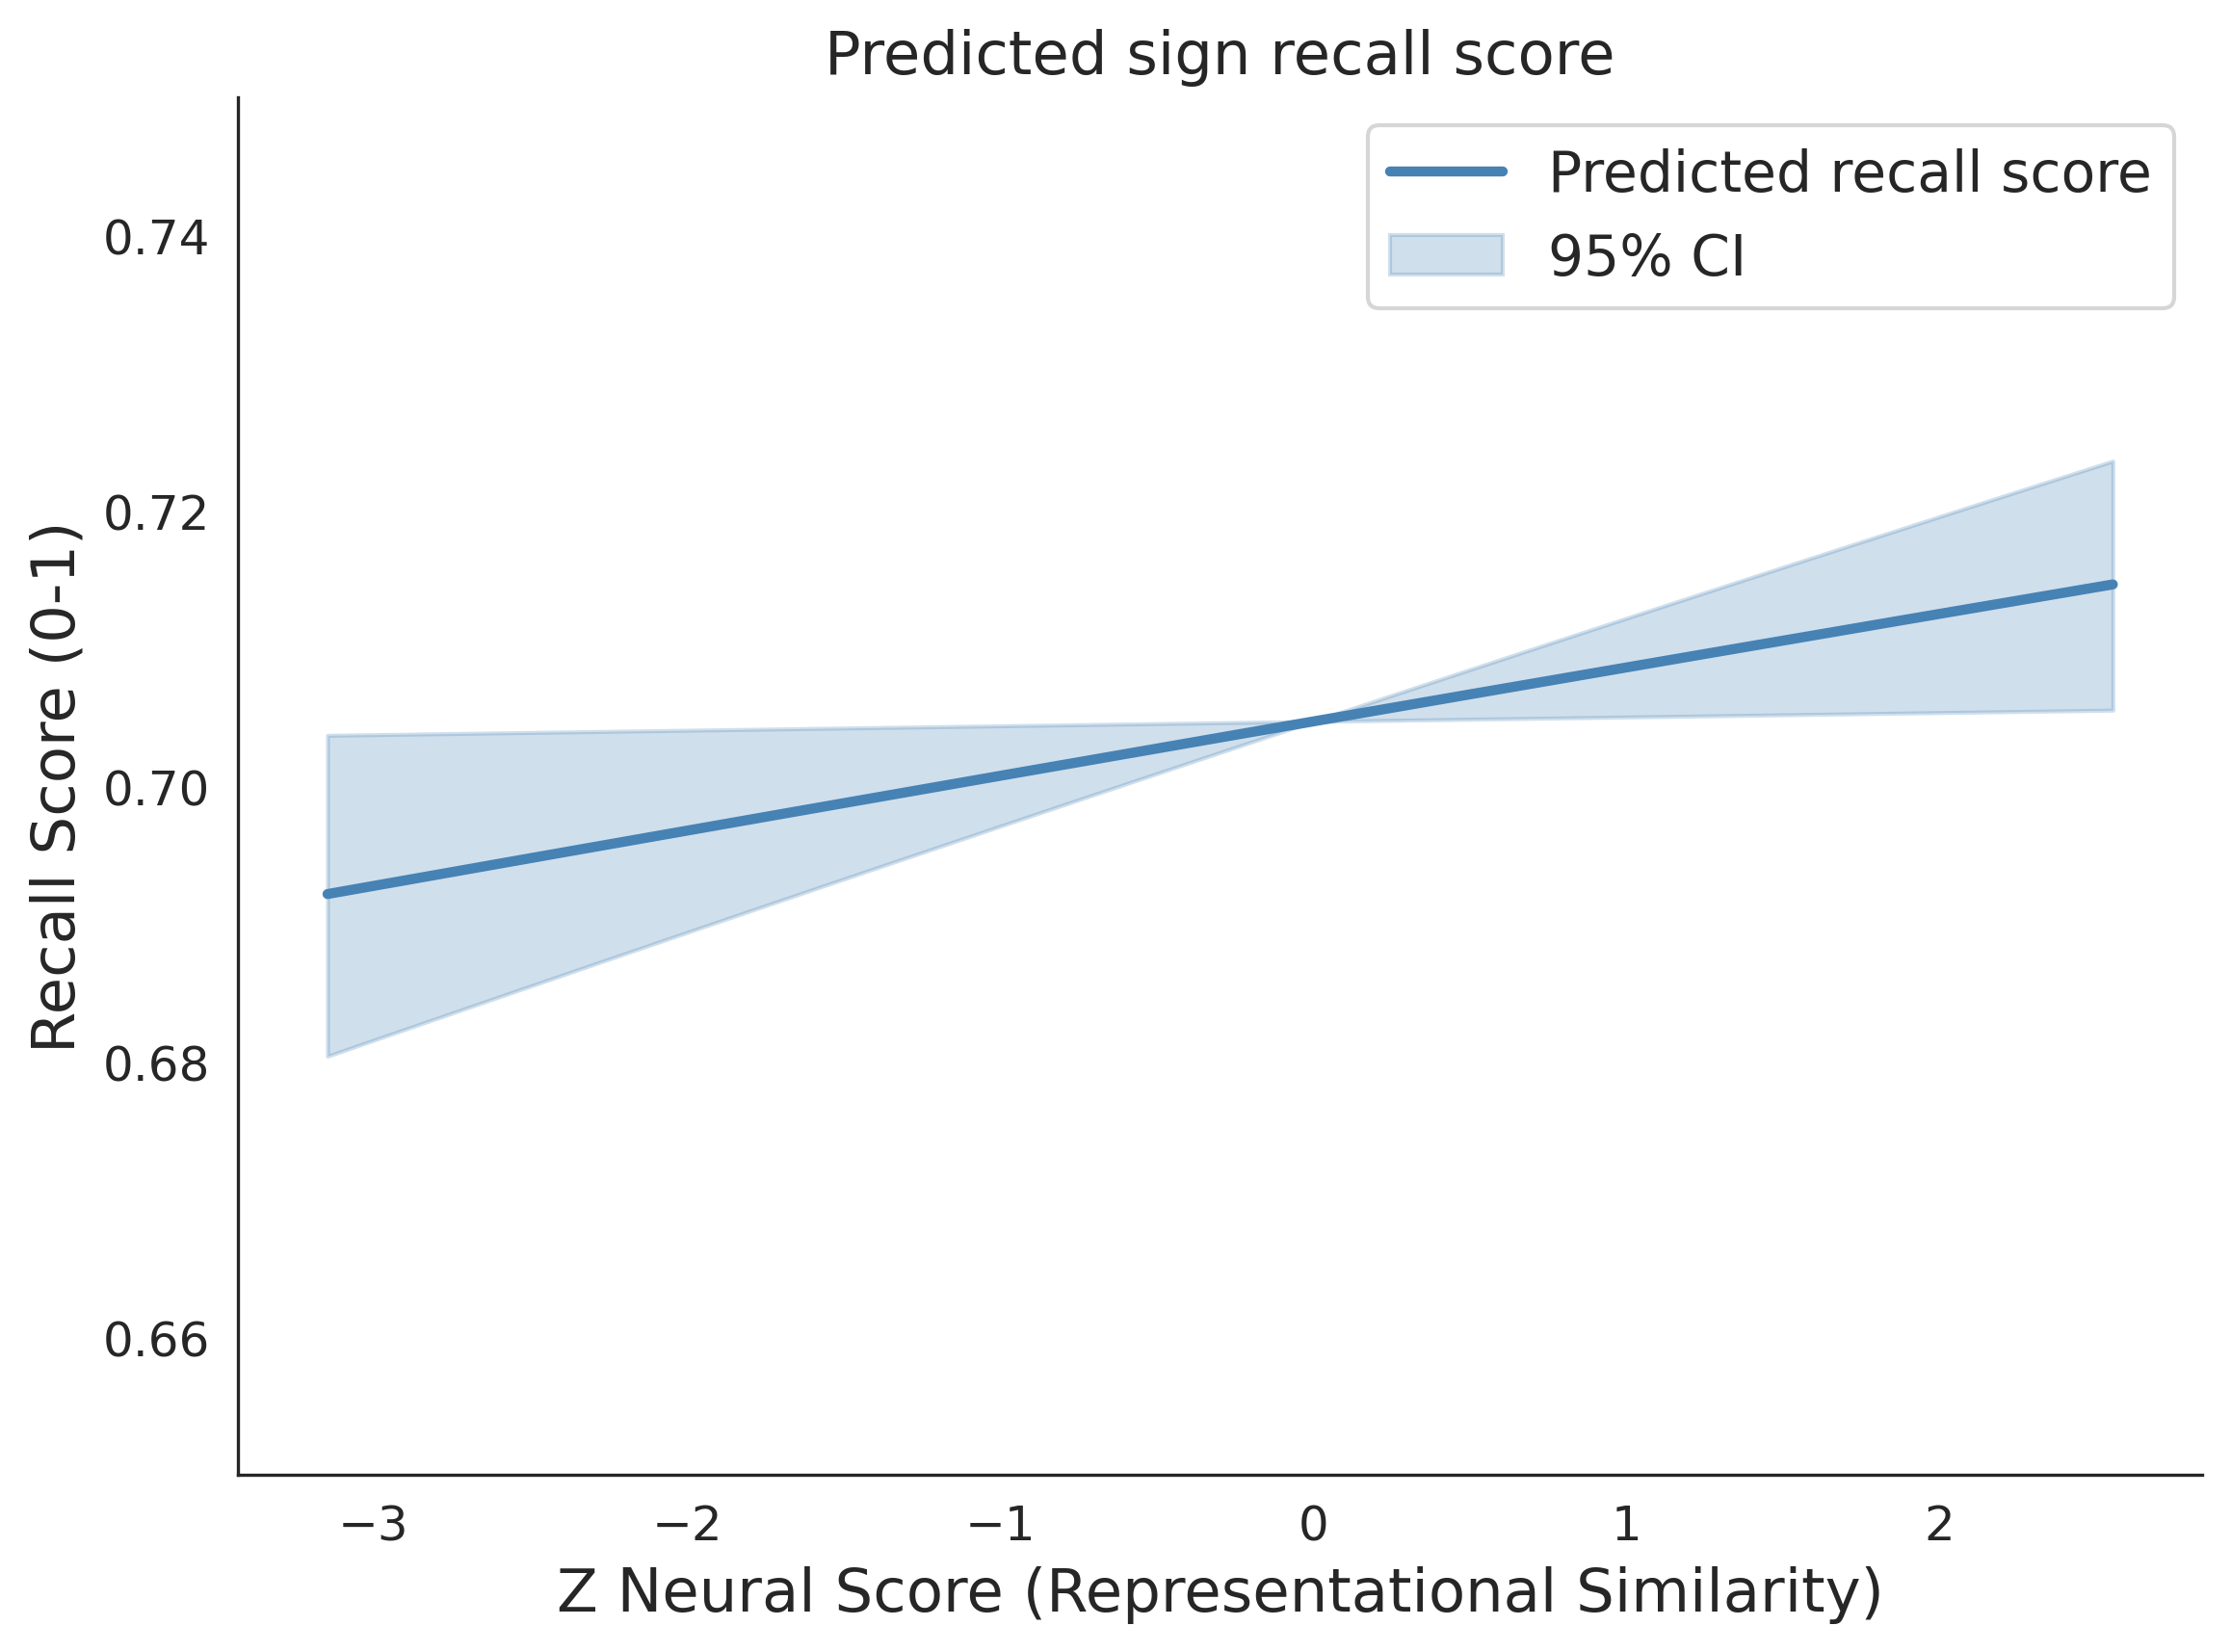

In [112]:
# Extract fixed effects from fitted model
intercept = model.coefs.loc['(Intercept)', 'Estimate']
slope     = model.coefs.loc['neuralscore_norm',  'Estimate']
se_slope  = model.coefs.loc['neuralscore_norm',  'SE']

# Create range of neural score values
x = np.linspace(scores_long['neuralscore_norm'].min(),
                scores_long['neuralscore_norm'].max(), 300)

# Predicted log-odds and probability
log_odds = intercept + slope * x
prob     = expit(log_odds)

# Confidence band (on log-odds scale, then transform)
log_odds_upper = intercept + (slope + 1.96 * se_slope) * x
log_odds_lower = intercept + (slope - 1.96 * se_slope) * x
prob_upper = expit(log_odds_upper)
prob_lower = expit(log_odds_lower)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(x, prob, color='steelblue', linewidth=2.5, label='Predicted recall score')
ax.fill_between(x, prob_lower, prob_upper,
                alpha=0.25, color='steelblue', label='95% CI')

ax.set_xlabel('Z Neural Score (Representational Similarity)', fontsize=15)
ax.set_ylabel('Recall Score (0-1)', fontsize=15)
ax.set_title('Predicted sign recall score', fontsize=15)
ax.set_ylim(0.65, 0.75)
# ax.set_yticks([.6,.55,.5,.45,.4],labels=[0.60,0.55,0.50,0.45,0.40],size=13)
# ax.set_xticks([0,.25,.5,.75,1,1.25,1.5,1.75,2],labels=[0,0.25,0.5,0.75,1.00,1.25,1.50,1.75,2.00],size=13)
ax.legend(fontsize=14)
sns.despine()
plt.tight_layout()
plt.show()

In [113]:
betas=[]
ps=[]
ci_uppers=[]
ci_lowers=[]
se = []
r_marg = []

for c in np.unique(list(scores_known['cluster'])):
    df = scores_known[scores_known['cluster'] == c]

    df['neuralscore_c'] = stats.zscore(df['neuralscore'])

    model = pymer4.Lmer("recall_score ~ neuralscore_c + (1|parc) + (1|subID) + (1|item)",data=df);
    results_df = model.fit()
    betas.append(list(results_df['Estimate'])[1])
    ps.append(list(results_df['P-val'])[1])
    ci_uppers.append(list(results_df['97.5_ci'])[1])
    ci_lowers.append(list(results_df['2.5_ci'])[1])
    se.append(list(results_df['SE'])[1])
    marg, cond = r2_nakagawa_gaussian(model)
    r_marg.append(marg)
        
false_discovery_control(ps)

boundary (singular) fit: see help('isSingular') 

Linear mixed model fit by REML [’lmerMod’]
Formula: recall_score~neuralscore_c+(1|parc)+(1|subID)+(1|item)

Family: gaussian	 Inference: parametric

Number of observations: 7680	 Groups: {'subID': 40.0, 'item': 24.0, 'parc': 16.0}

Log-likelihood: 1128.247 	 AIC: -2244.495

Random effects:

                 Name    Var    Std
subID     (Intercept)  0.011  0.107
item      (Intercept)  0.011  0.104
parc      (Intercept)  0.000  0.000
Residual               0.042  0.205

No random effect correlations specified

Fixed effects:

boundary (singular) fit: see help('isSingular') 

Linear mixed model fit by REML [’lmerMod’]
Formula: recall_score~neuralscore_c+(1|parc)+(1|subID)+(1|item)

Family: gaussian	 Inference: parametric

Number of observations: 9120	 Groups: {'subID': 40.0, 'item': 24.0, 'parc': 19.0}

Log-likelihood: 1362.379 	 AIC: -2712.758

Random effects:

                 Name    Var    Std
subID     (Intercept)  0.011  0.107
item  

array([0.024     , 0.415     , 0.19866667, 0.024     ])

In [75]:
r_marg

[0.0005600743351644516,
 5.272358620082704e-05,
 0.0012222241560877044,
 0.0007412049902435898]

[0.024      0.415      0.19866667 0.024     ]


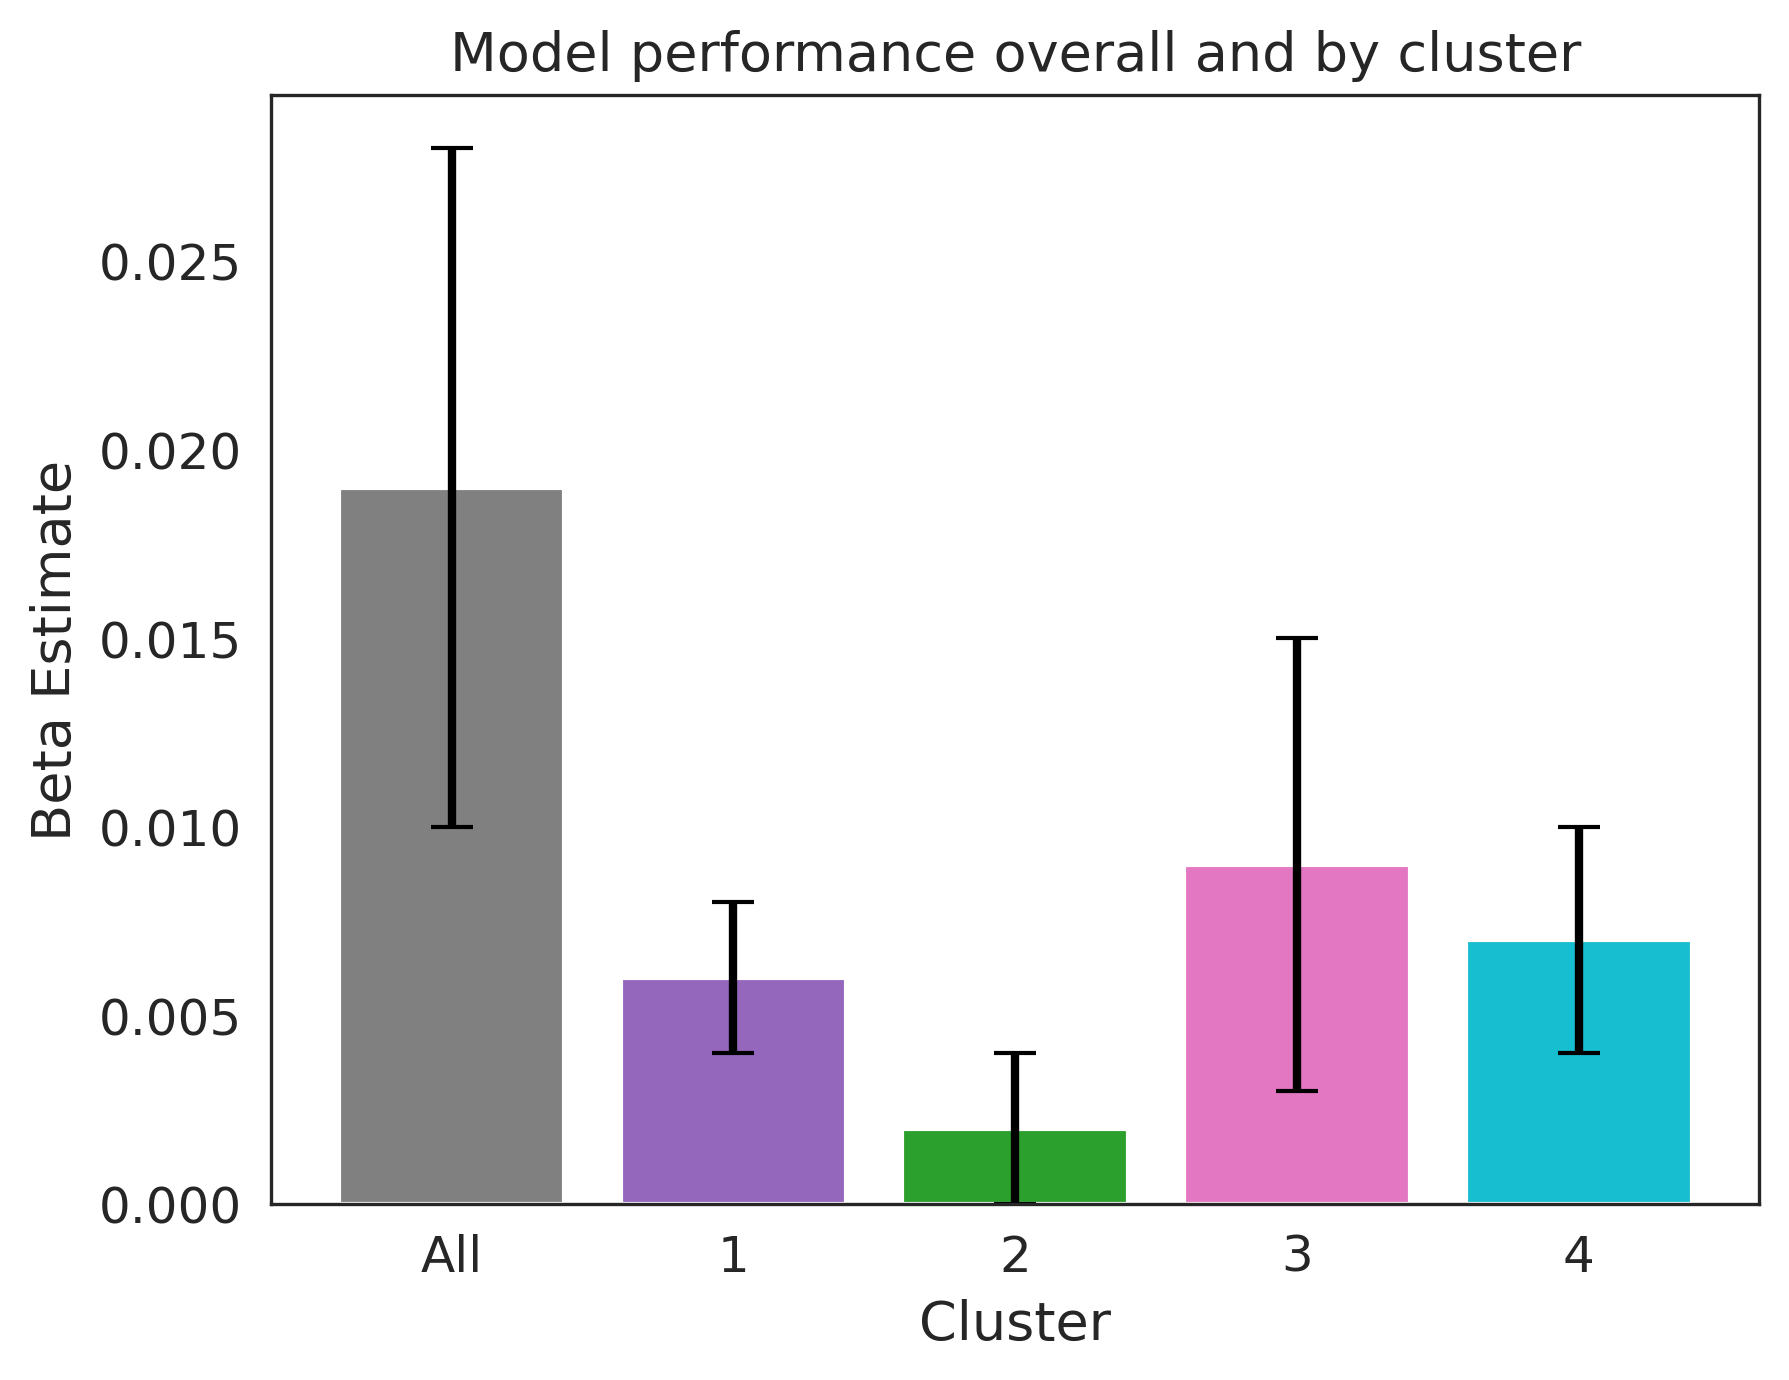

In [116]:
print(false_discovery_control(ps))

all_betas=[beta_obs]+betas
all_ps=[p_obs]+list(false_discovery_control(ps))
# all_se = [se_obs]+se
colors = ['grey'] + cluster_colors

plt.bar(range(len(all_betas)), all_betas, color=colors,capsize=5,yerr=all_se) #yerr=[error_lower, error_upper])
plt.title("Model performance overall and by cluster",fontsize=13)
plt.xlabel("Cluster",fontsize=13)
plt.ylabel("Beta Estimate",fontsize=13)
plt.xticks(np.arange(k+1),labels=['All'] + [str(n) for n in range(1,k+1)]);

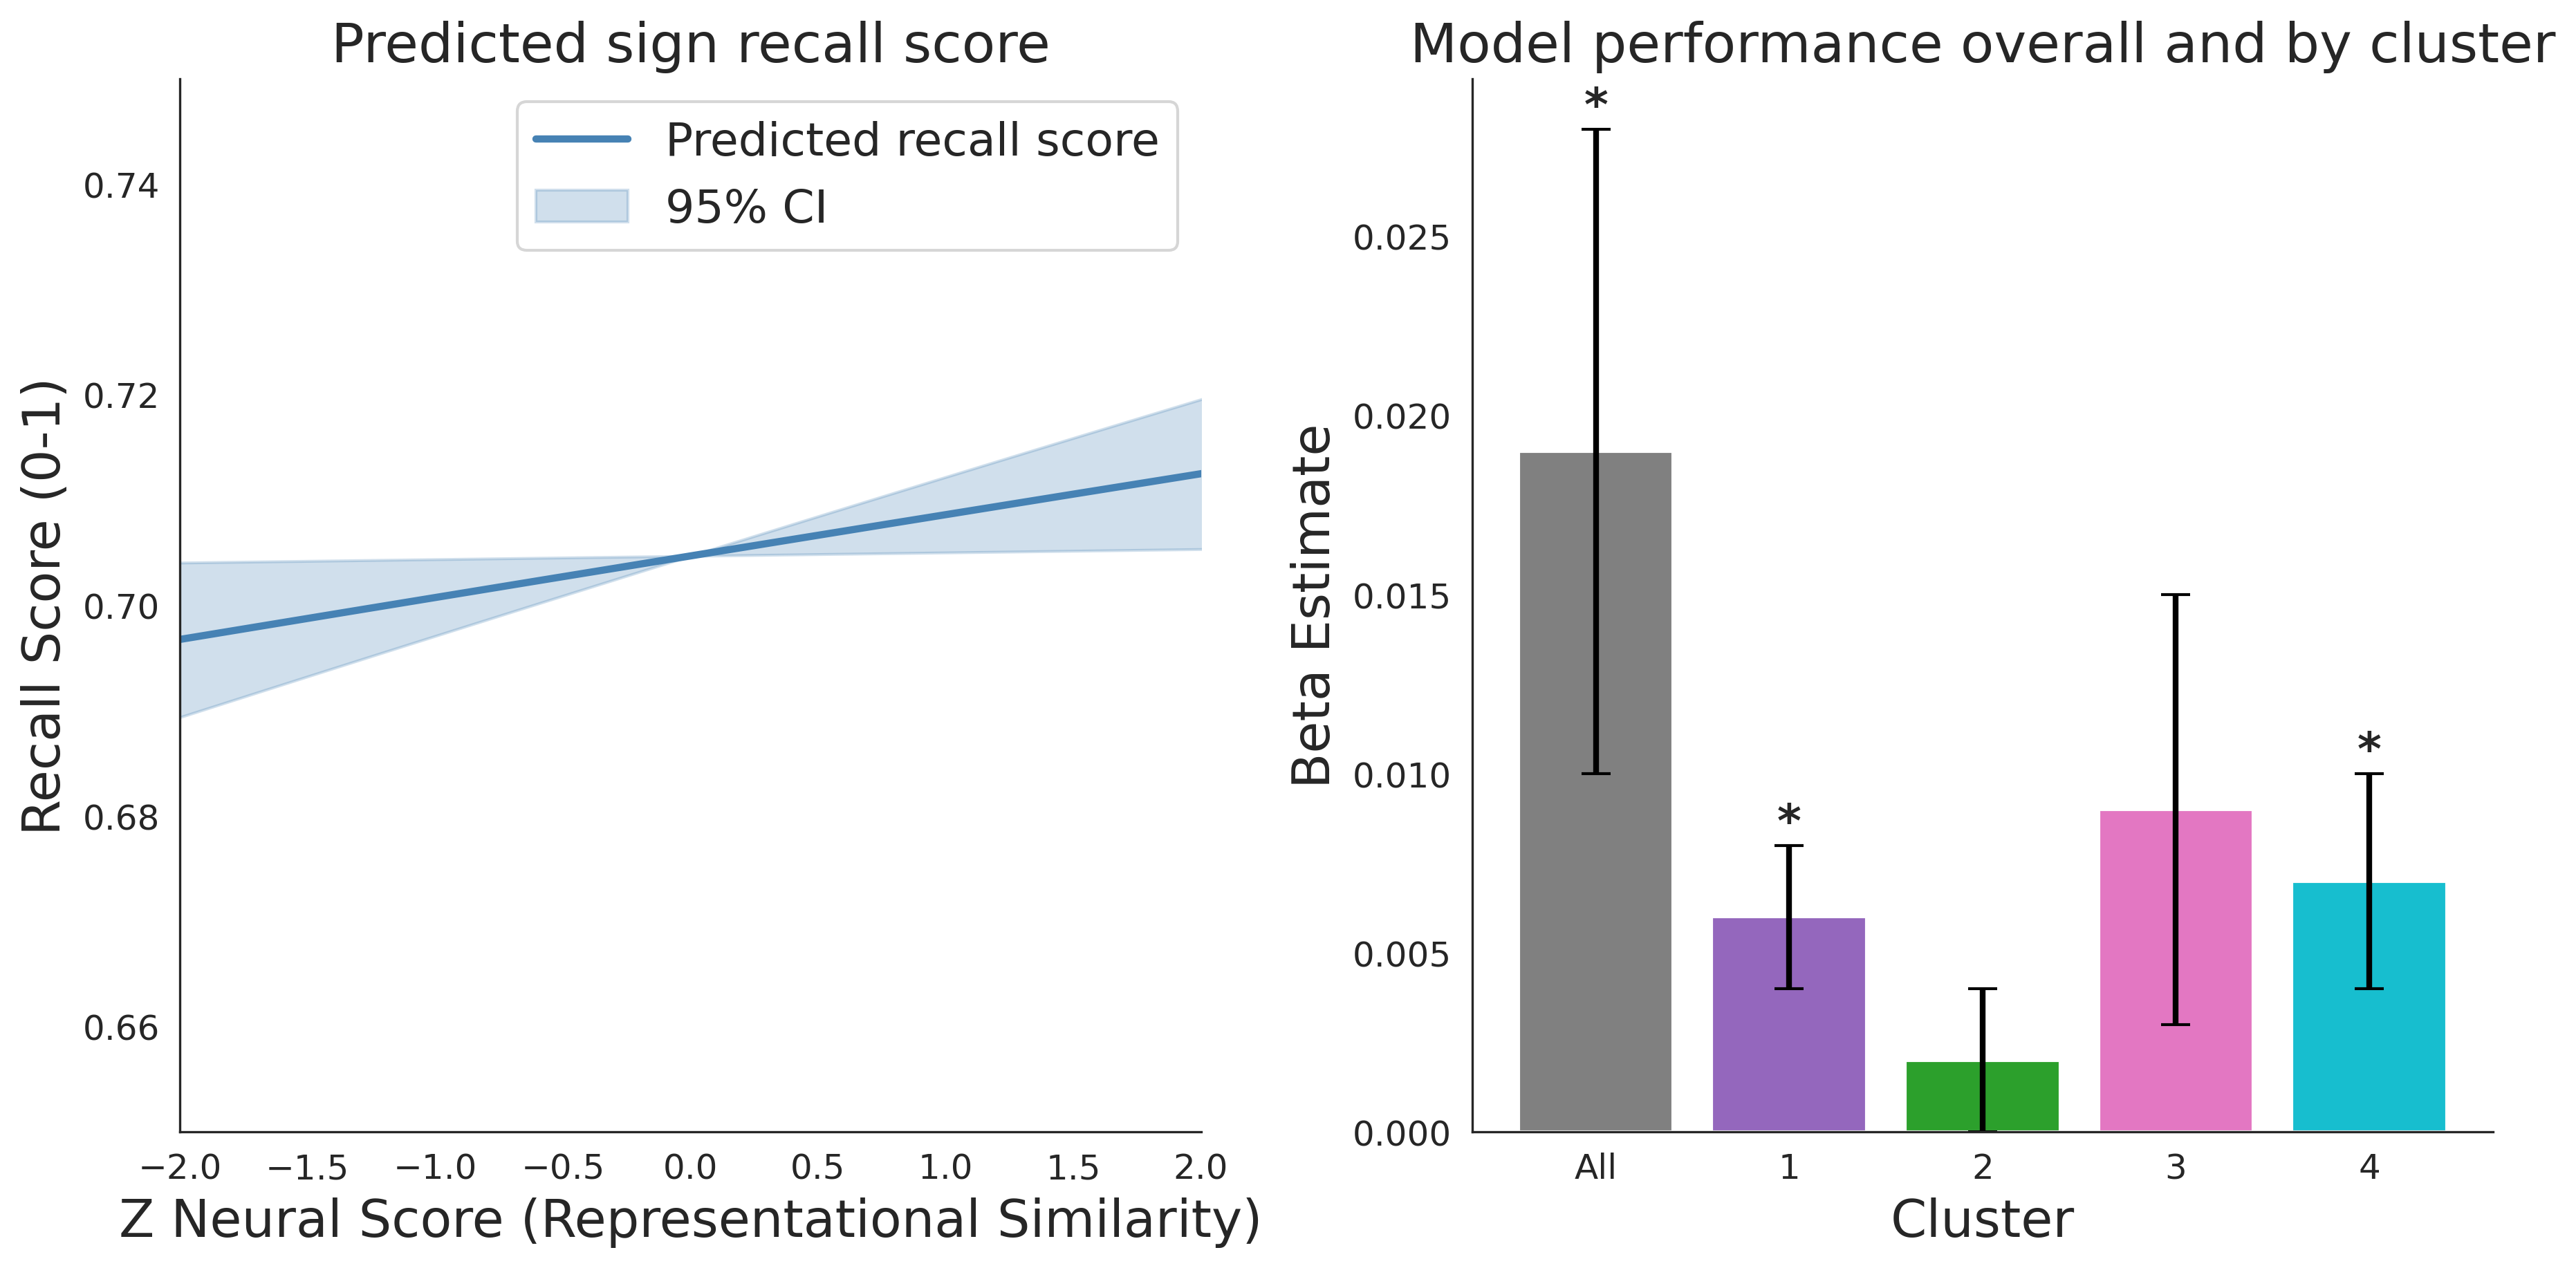

In [117]:
# Combination plot with both linear model and by-cluster betas:

sns.set_style("white")
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 19,
    "axes.labelsize": 18, 
    "legend.fontsize": 16,
    "xtick.labelsize": 12, 
    "ytick.labelsize": 12,
    "lines.linewidth": 2,
    "figure.dpi": 300
})
fig, (ax1, ax2) = plt.subplots(nrows=1,ncols=2, figsize=(12, 6),constrained_layout=True,gridspec_kw={"wspace":0.05})

# regression plot
ax1.plot(x, prob,color="steelblue",linewidth=2.5,label="Predicted recall score")

# regression CI band
ax1.fill_between(x,prob_lower,prob_upper,color="steelblue",alpha=0.25,label="95% CI")

ax1.set_xlabel("Z Neural Score (Representational Similarity)")
ax1.set_ylabel("Recall Score (0-1)")
ax1.set_title("Predicted sign recall score")
ax1.axhline(0.5, color="gray", linestyle="--", linewidth=1.5, alpha=0.8)
ax1.set_xlim(-2,2)
ax1.set_ylim(0.65, 0.75)

ax1.legend()
sns.despine(ax=ax1)

bars = ax2.bar(np.arange(len(all_betas)),all_betas, color=colors, yerr=all_se, capsize=5,)

ax2.set_title("Model performance overall and by cluster")
ax2.set_xlabel("Cluster")
ax2.set_ylabel("Beta Estimate")

ax2.set_xticks(np.arange(k + 1))
ax2.set_xticklabels(["All"] + [str(n) for n in range(1, k + 1)])

# add significance stars
for bar, p, se in zip(bars, all_ps, all_se):
    if p <= 0.001:
        star = "***"
    elif p < 0.01:
        star = "**"
    elif p < 0.05:
        star = "*"
    else:
        continue

    height = bar.get_height()
    x_center = bar.get_x() + bar.get_width() / 2.0
    y_pos = height + se
    ax2.text(x_center, y_pos, star, ha="center", va="bottom",fontsize=16,fontweight='bold')

sns.despine(ax=ax2)
